# Automated Egg Damage Detection Using Deep Learning

**i. INTRODUCTION**

Nama : Muhammad Ali Fikri <br>
Batch : RMT - 053<br>  
Problem Statement : <br>
Egg collection in poultry farms requires timely monitoring to maintain product quality and farm cleanliness. However, Mr. Gofar experienced difficulties in consistently monitoring and collecting eggs at the right time. As a result, some eggs were left in the coop for too long, increasing the risk of damage such as cracks or breakage, which also negatively affected the cleanliness and overall condition of the farm environment.

To address this issue, an automated solution was proposed to assist the egg collection process. This project focuses on developing a Machine Learning-based Computer Vision model capable of classifying eggs into two categories: damaged eggs and non-damaged eggs. The system is expected to support faster and more accurate identification of egg conditions before the collection process.
  

Objektif : <br>
The objective of this project is to develop a Computer Vision Machine Learning model that can automatically classify egg conditions into two categories: damaged and non-damaged eggs. The model is designed to assist in improving efficiency, maintaining egg quality, and supporting a more effective egg monitoring and collection process.

**ii. IMPORT LIBRARIES**

In [1]:
#import libraries
from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, Input, Dropout, BatchNormalization
from sklearn.metrics import confusion_matrix, classification_report

**iii. DATA LOADING**

The dataset used in this project was initially downloaded from Kaggle and then stored in Google Drive so it could be easily accessed and processed within this notebook environment.

In this case, the dataset only provided two main folders: damaged eggs and non-damaged eggs. To ensure the model could be evaluated fairly using completely unseen data, 10% of the images from each category were separated and used as a test set.

This approach helps measure how well the model performs on new data and ensures that the evaluation process is more reliable and realistic.

In [ ]:
#Link a notebook file to Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Create a directory path for the training and test sets
base_dir = '/content/drive/MyDrive/GC7_HACKTIV8/Eggs Classification' #Adjust with your directory path in Google Drive
train_file= base_dir + '/train_set'
test_file= base_dir +'/test_set'

**iv. EXPLORATORY DATA ANALYSIS (EDA)**

In [ ]:
#function to display images for each class in a single folder
def plot_images(path):
  labels = os.listdir(path)
  for label in labels:
    folder_path = os.path.join(path, label)
    fig = plt.figure(figsize=(10, 10))
    columns = 6
    rows = 1
    print('Class : ', label)
    images = os.listdir(folder_path)
    for index in range(1, columns*rows +1):
        fig.add_subplot(rows, columns, index)
        image = plt.imread(os.path.join(folder_path, images[index]))
        plt.imshow(image)
        plt.axis("off")
    plt.show()

Class :  damaged


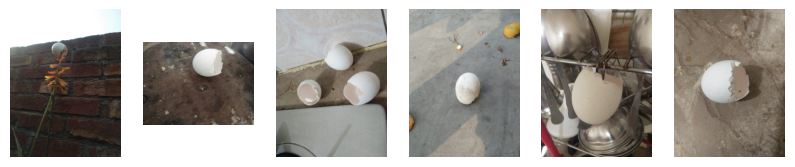

Class :  not_damaged


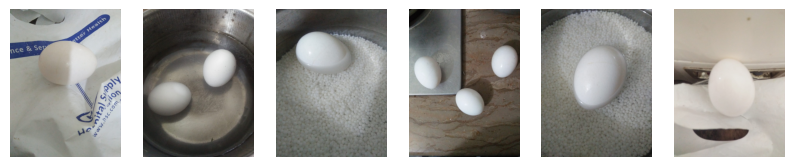

In [ ]:
#visualizing images in the training data
plot_images(train_file)

After visualizing sample images from both classes — damaged and non-damaged eggs — several distinguishing characteristics were identified for each category.

Damaged Eggs:  
* The egg shape is often incomplete or irregular instead of having a smooth oval form.
* The shell surface may appear cracked or jagged around the edges.
* Some images show darker inner areas or shadows within the egg shape, indicating possible structural damage.

Non-Damaged Eggs:  
* The eggs generally have a smooth and well-defined oval shape.
* The shadow and contour appear clean and consistent, closely resembling a complete egg structure.
* The shell color and surface texture tend to be more uniform and visually consistent.

**v. FEATURE ENGINEERING**

*   Pre Processing

Before being processed by the model, the dataset was first prepared through several preprocessing steps. Each image was resized to 224 × 224 pixels to create a consistent input size and to ensure better compatibility for future model improvements, particularly if transfer learning techniques are applied later.  

During the training process, the dataset was divided into batches of 32 images to make the training process more efficient and manageable.

In [ ]:
#define hyperparameter
img_height= 224
img_width= 224
batch_size= 32


Since the original dataset did not include a separate validation set, a portion of the training data was split into training and validation datasets. This validation set is important for monitoring the model’s performance during training and reducing the risk of overfitting.

In addition, data augmentation techniques were applied to help the model learn from more diverse image variations and viewing perspectives. This step allows the model to become more robust when handling different egg positions, orientations, and shapes.  

The augmentation techniques used in this project include:  

    - Horizontal Flip
    - Vertical Flip
    - Rotation
    - Zoom

By applying these augmentations, the model is expected to generalize better and perform effectively across various real-world egg conditions.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255., #change the scale to 0 to 1
    rotation_range=45, #The image is rotated 45 degrees
      zoom_range=0.2, #The image is zoomed in and out by about 20%
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.2) #set aside 20% of the training data for validation

*   TRAIN-SET

In [ ]:
train_data = train_datagen.flow_from_directory(
    train_file,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',  #The `class_mode` is set to ‘binary’ because the targets in this case are ‘damaged’ and ‘undamaged,’ or 0 and 1
    subset='training',
    shuffle=True,
    seed=31
)

Found 572 images belonging to 2 classes.


*   VAL-SET

In [9]:
val_data = train_datagen.flow_from_directory(
    train_file,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    shuffle=True,
    seed=31
)

Found 142 images belonging to 2 classes.




*   TEST-SET




In [10]:
test_datagen = ImageDataGenerator(rescale=1./255.)

test_data = test_datagen.flow_from_directory(
    test_file,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False,
    seed=31
)

Found 80 images belonging to 2 classes.


In [ ]:
#checking mapping labels
print("Train:", train_data.class_indices)
print("Test :", test_data.class_indices)

Train: {'damaged': 0, 'not_damaged': 1}
Test : {'damaged': 0, 'not_damaged': 1}


The dataset used in this project was divided into three subsets:

* Train Set: 572 images
* Validation Set: 142 images
* Test Set: 80 images

These datasets consist of chicken egg images categorized into two classes:

* Damaged Eggs → labeled as 0
* Non-Damaged Eggs → labeled as 1

The model was trained using the training set, while the validation set was used during training to monitor performance and evaluate how well the model generalized to unseen data.

After obtaining the best-performing model based on the evaluation results, the final model was tested using the test set, which contains completely unseen data. This final testing stage helps measure the model’s real-world performance and overall classification capability.

**vi. ANN TRAINING (Sequential API/Functional API)**

**vi.1. Model Definition**

In [12]:
# Clear session
seed = 31
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

In this case, a model using the sequential API method was used because the author wanted to observe the model training process in a more sequential manner.

The model architecture used in this project consists of three convolutional layers with an increasing number of neurons (16, 32, and 64 filters). This layered approach allows the model to progressively capture more detailed visual features, including egg contours, texture patterns, and possible crack indications along the shell surface.

After the convolutional process, a Dense layer with 256 neurons was applied to combine and interpret the extracted features from the previous layers, enabling the model to perform deeper and more effective classification.

The ReLU (*Rectified Linear Unit*) activation function was used in each hidden layer due to its efficiency in accelerating the training process and its ability to help reduce the risk of the vanishing gradient problem during model learning.

For the output layer, the Sigmoid activation function was implemented along with the Binary Crossentropy loss function, since this project focuses on a binary classification task: distinguishing between damaged and non-damaged eggs.

In [13]:
#Create sequential API model
model_aug = Sequential()
model_aug.add(Conv2D(16, (3,3), activation='relu', input_shape=(img_height, img_width,3)))
model_aug.add(MaxPooling2D(2, 2))
model_aug.add(Conv2D(32, (3,3), activation='relu'))
model_aug.add(MaxPooling2D(2, 2))
model_aug.add(Conv2D(64, (3,3),activation='relu'))
model_aug.add(MaxPooling2D(2, 2))
model_aug.add(Flatten())
model_aug.add(Dense(256, activation='relu'))
model_aug.add(Dense(1, activation='sigmoid'))

# Compile
model_aug.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
model_aug.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    11,075,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,099,681 (42.34 MB)

 Trainable params: 11,099,681 (42.34 MB)

 Non-trainable params: 0 (0.00 B)

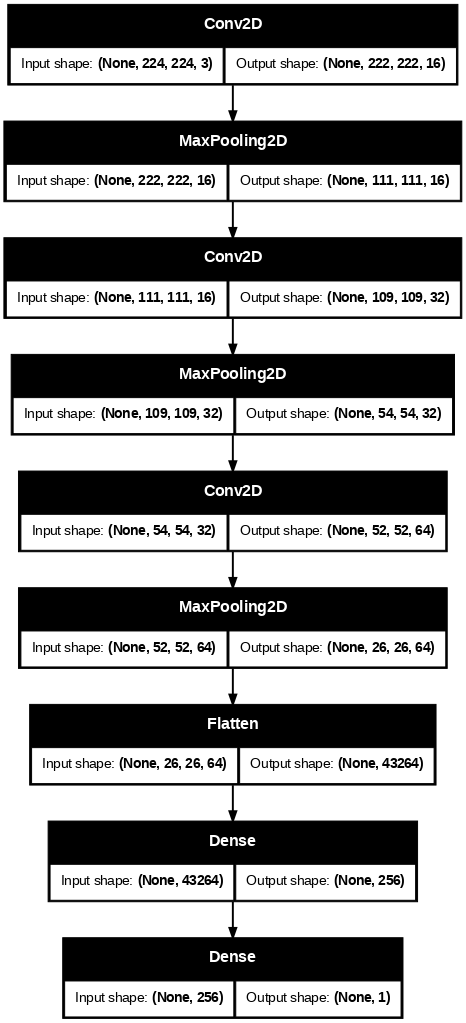

In [14]:
# Plot layers

tf.keras.utils.plot_model(model_aug, show_shapes=True, dpi=70)

**vi.2. Model Training**

During the training process, the model was compiled using the Adam optimizer, which is widely known for its adaptive and efficient approach in updating model weights during learning.

The model’s performance was evaluated using the accuracy metric. Initially, the model was trained for 25 epochs to observe its baseline performance and overall learning capability.

If the resulting performance was considered insufficient or not yet optimal, further improvements and parameter tuning would be carried out to enhance the model’s effectiveness.

In [15]:
# Train the model

%%time
history_aug = model_aug.fit(train_data, epochs=25, validation_data=val_data, batch_size=batch_size)

Epoch 1/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.7483 - loss: 0.7716 - val_accuracy: 0.7958 - val_loss: 0.5234
Epoch 2/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7972 - loss: 0.4976 - val_accuracy: 0.7958 - val_loss: 0.5206
Epoch 3/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.7850 - loss: 0.4945 - val_accuracy: 0.7958 - val_loss: 0.5414
Epoch 4/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7972 - loss: 0.4818 - val_accuracy: 0.7958 - val_loss: 0.5032
Epoch 5/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8427 - loss: 0.3954 - val_accuracy: 0.8028 - val_loss: 0.4666
Epoch 6/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8584 - loss: 0.3538 - val_accuracy: 0.8028 - val_loss: 0.4512
Epoch 7/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8706 - loss: 0.3452 - val_accuracy: 0.8169 - val_loss: 0.4113
Epoch 8/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8531 - loss: 0.3547 - val_accuracy: 0.8099 - val_loss:

**vi.3. Model Evaluation**

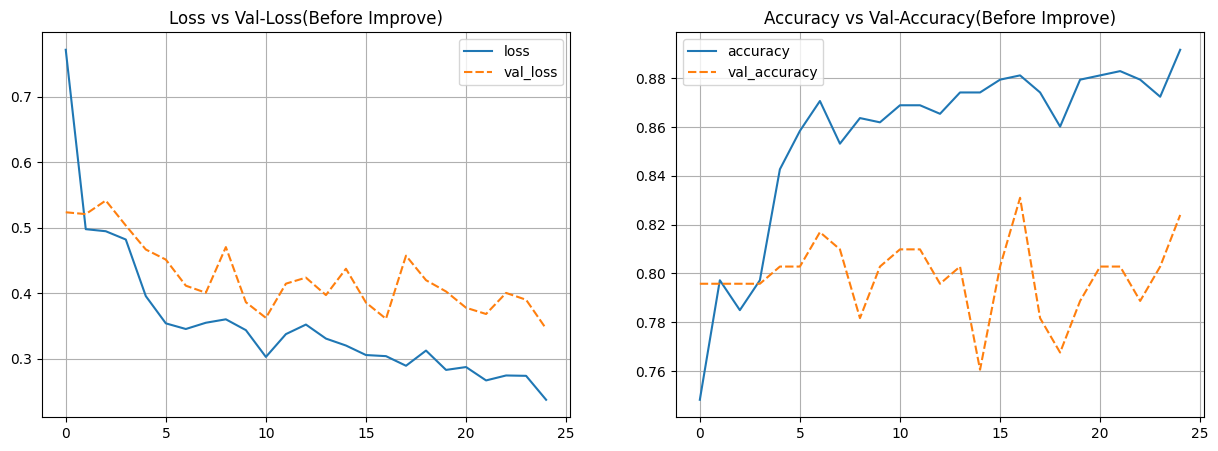

In [16]:
# Plot training results

history_aug_df = pd.DataFrame(history_aug.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.lineplot(data=history_aug_df[['loss', 'val_loss']])
plt.grid()
plt.title('Loss vs Val-Loss(Before Improve)')

plt.subplot(1, 2, 2)
sns.lineplot(data=history_aug_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Accuracy vs Val-Accuracy(Before Improve)')
plt.show()

Based on the evaluation results of the baseline model, there is a noticeable gap between the training loss and validation loss. The training loss shows a steady and consistent decrease, indicating that the model is learning effectively from the training data. Meanwhile, the validation loss also tends to decrease but appears significantly more fluctuating.

This behavior suggests that the baseline model has successfully learned the training patterns, but it still struggles to generalize well when faced with new or unseen images.

In terms of accuracy, the training accuracy increased significantly and reached approximately 89%, while the validation accuracy fluctuated between 76% and 82%. This pattern indicates that the model is showing signs of overfitting, where the model becomes too focused on memorizing the training data rather than learning generalized features.

Although the validation accuracy range of 76–82% indicates that the model is still capable of performing classification tasks reasonably well, the instability in performance highlights the need for further improvements. Enhancements could be made through adjustments to the model architecture, hyperparameter tuning, or the application of regularization techniques in order to achieve more stable and reliable performance.

**vii. ANN IMPROVEMENT (Sequential API/Functional API)**

Since the evaluation results from the previous model still indicated an overfitting issue, with a considerable gap between the training and validation loss and accuracy values, further improvements were necessary.

Therefore, adjustments to the model architecture and training parameters were carried out in order to achieve better generalization performance and produce a more stable and reliable model.

**vii.1. Model Definition**

During the improvement stage, several adjustments were made to the model parameters, particularly through the implementation of *Dropout layers* and the reduction of neurons in the *Dense layer*.

The Dropout technique was applied to randomly deactivate certain neurons during the training process. This approach prevents the model from becoming overly dependent on specific neurons, making the model more robust and significantly more effective in reducing *overfitting*.

In addition, the number of neurons in the Dense layer was reduced to simplify the overall model complexity. Models that are too complex tend to memorize training data rather than learning generalized patterns. By simplifying the architecture, the model is encouraged to focus on learning more meaningful and generalizable features, ultimately improving its ability to perform better on unseen data.


In [17]:
# Clear session
seed = 31
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

In [18]:
#MODEL IMPROVEMENT
#Create sequential API model
model_aug_imp = Sequential()

model_aug_imp.add(Conv2D(16, (3,3), activation='relu', input_shape=(img_height, img_width,3)))
model_aug_imp.add(MaxPooling2D(2, 2))

model_aug_imp.add(Conv2D(32, (3,3), activation='relu'))
model_aug_imp.add(MaxPooling2D(2, 2))

model_aug_imp.add(Conv2D(64, (3,3),activation='relu'))
model_aug_imp.add(MaxPooling2D(2, 2))

model_aug_imp.add(Flatten())

model_aug_imp.add(Dense(128, activation='relu')) #mengurangi neuron layer
model_aug_imp.add(Dropout(0.3))  #tambah dropout
model_aug_imp.add(Dense(1, activation='sigmoid'))

# Compile
model_aug_imp.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])
model_aug_imp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,561,633 (21.22 MB)

 Trainable params: 5,561,633 (21.22 MB)

 Non-trainable params: 0 (0.00 B)

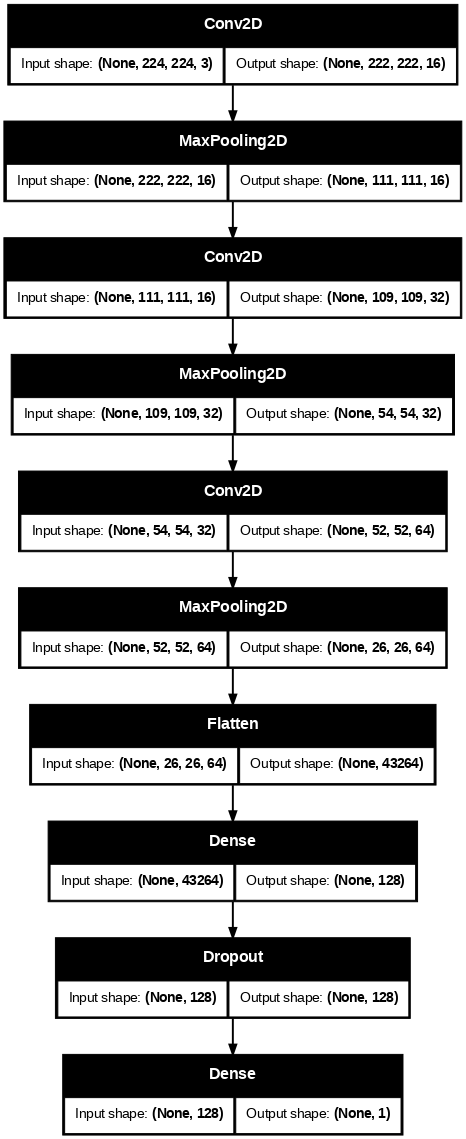

In [19]:
# Plot layers

tf.keras.utils.plot_model(model_aug_imp, show_shapes=True, dpi=70)

**vii.2. Model Training**

In [20]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True)

An Early Stopping mechanism was also implemented during the training process. This technique automatically stops the training when the model’s validation loss (val_loss) continues to increase over several consecutive epochs.

The purpose of using Early Stopping is to prevent the model from learning excessively (over-training), which can worsen overfitting. In addition, this method helps make the training process more efficient by avoiding unnecessary training epochs once the model performance no longer improves.

In [21]:
# Train the model

%%time
history_aug_imp = model_aug_imp.fit(train_data,
                                    epochs=25,
                                    validation_data=val_data,
                                    batch_size=batch_size,
                                    callbacks =[early_stop]
                              )

Epoch 1/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7710 - loss: 0.6333 - val_accuracy: 0.7958 - val_loss: 0.5415
Epoch 2/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7972 - loss: 0.4908 - val_accuracy: 0.7958 - val_loss: 0.5343
Epoch 3/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.7972 - loss: 0.4918 - val_accuracy: 0.7958 - val_loss: 0.5325
Epoch 4/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8094 - loss: 0.4414 - val_accuracy: 0.7958 - val_loss: 0.5105
Epoch 5/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8374 - loss: 0.3952 - val_accuracy: 0.8028 - val_loss: 0.4276
Epoch 6/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8427 - loss: 0.3781 - val_accuracy: 0.7887 - val_loss: 0.4723
Epoch 7/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8129 - loss: 0.3914 - val_accuracy: 0.8028 - val_loss: 0.4559
Epoch 8/25
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8287 - loss: 0.4125 - val_accuracy: 0.7606 - val_loss:

**vii.3. Model Evaluation**

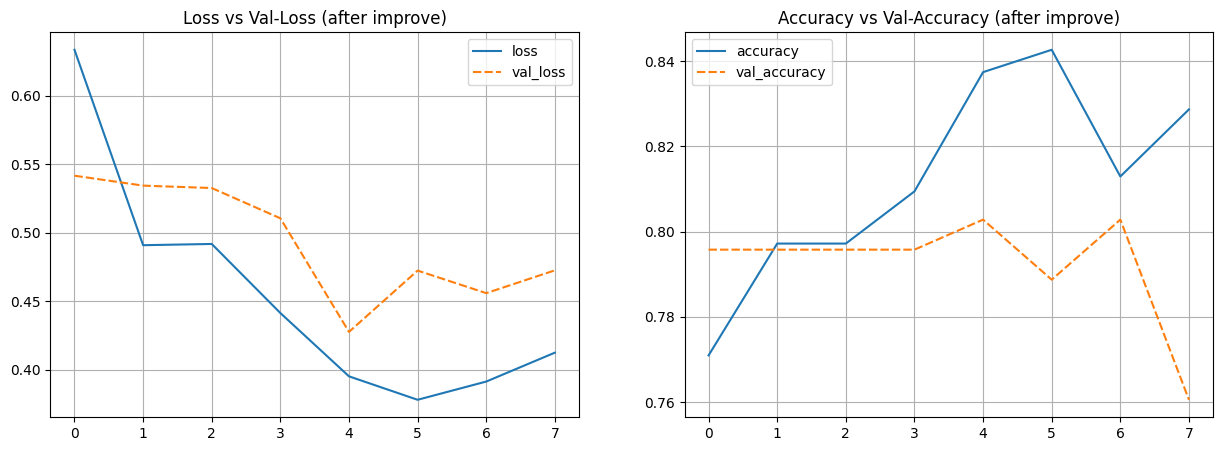

In [22]:
history_aug_imp_df = pd.DataFrame(history_aug_imp.history)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.lineplot(data=history_aug_imp_df[['loss', 'val_loss']])
plt.grid()
plt.title('Loss vs Val-Loss (after improve)')

plt.subplot(1, 2, 2)
sns.lineplot(data=history_aug_imp_df[['accuracy', 'val_accuracy']])
plt.grid()
plt.title('Accuracy vs Val-Accuracy (after improve)')
plt.show()

Based on the evaluation results of the improved model, the training process stopped at epoch 8, indicating that the model had already reached its optimal performance early in the training stage. This also suggests that additional training was unnecessary and could potentially lead to overfitting.

From the loss graph, the gap between the training loss and validation loss became noticeably smaller compared to the baseline model. In addition, the validation loss of the improved model appeared more stable, which indicates that the improved architecture was better at generalizing to unseen data rather than simply memorizing the training dataset.

The accuracy graph also demonstrates better overall performance. The gap between training accuracy and validation accuracy was significantly smaller than in the baseline model, showing that the model achieved a more balanced learning process between training performance and validation performance.

Overall, the improved model delivered more stable and efficient results, both in terms of training time and its ability to generalize effectively on new data.

- Testing model with new data (Test-set)

In [23]:
# Check the performance of test-set

## Get the probability
y_pred_aug = model_aug_imp.predict(test_data)

## Get class with maximum probability
y_pred_class_aug = np.argmax(y_pred_aug, axis=-1)

## Display Classification Report
print(classification_report(test_data.classes, y_pred_class_aug, target_names=np.array(list(train_data.class_indices.keys()))))

3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 7s/step
              precision    recall  f1-score   support

     damaged       0.79      1.00      0.88        63
 not_damaged       0.00      0.00      0.00        17

    accuracy                           0.79        80
   macro avg       0.39      0.50      0.44        80
weighted avg       0.62      0.79      0.69        80



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


After being evaluated on the test set, the model achieved a relatively high accuracy score of 79%. However, a deeper analysis of the classification report revealed that the model performance was still imbalanced across the two classes.

As shown in the evaluation results, the model achieved a recall score of 1.00 for the damaged egg class, indicating that the model was highly effective at identifying damaged eggs. However, the precision score of 0.79 suggests that not all predictions classified as damaged were actually correct. In other words, the model still produced some false positive predictions, although its overall performance remained reasonably good.

This condition is concerning because safe or non-damaged eggs could potentially be misclassified as damaged eggs, which may lead to unnecessary losses. This issue is further supported by the precision, recall, and F1-score values of 0.00 for the non-damaged egg class. In practice, this indicates that the model tended to predict almost all eggs as damaged.

These results suggest that the model experienced class bias, where the prediction behavior became heavily skewed toward one class — in this case, the damaged class — rather than learning balanced decision boundaries between damaged and non-damaged eggs.

Due to time limitations, the improved model was still selected for the inference stage because it demonstrated better overall training behavior, including faster training time and a smaller accuracy gap between the training and validation sets compared to the baseline model.

Nevertheless, the test-set evaluation clearly shows that the model still requires further improvements to achieve more balanced predictions and reduce bias between classes. Future enhancements could include additional data balancing techniques, architecture refinement, or more advanced regularization strategies to improve overall model reliability and generalization performance.

**viii. MODEL SAVING**

In [24]:
#model summary

model_aug_imp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,684,901 (63.65 MB)

 Trainable params: 5,561,633 (21.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,123,268 (42.43 MB)

Freeze the model so that the neuron values do not change

In [25]:
#freeze model

model_aug_imp.trainable=False
model_aug_imp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,684,901 (63.65 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 5,561,633 (21.22 MB)

 Optimizer params: 11,123,268 (42.43 MB)

In [26]:
# Save ANN model

model_aug_imp.save('model_comvis_gc7.keras', include_optimizer=True)

**ix. MODEL INFERENCE**

*Model inference is performed on a separate file named P2G7_muhalifikri_inference.ipynb*

**x. CONCLUSION**

This project successfully developed a Computer Vision-based Machine Learning model to classify chicken eggs into two categories: damaged and non-damaged eggs. The system was designed as a prototype solution to support automated egg monitoring and sorting in poultry farms, aiming to improve operational efficiency and reduce manual inspection.

Based on dataset analysis, damaged eggs generally showed irregular shapes, cracked edges, and darker inner shadows, while non-damaged eggs tended to have smoother shapes and more consistent appearances.

The baseline model was able to learn the dataset patterns but showed signs of overfitting due to the performance gap between training and validation results. To improve performance, several techniques such as Dropout and Early Stopping were applied, resulting in better training stability and improved generalization capability.

The improved model achieved better overall performance compared to the baseline model and showed strong capability in detecting damaged eggs. However, the model still demonstrated bias toward the damaged class, causing predictions for non-damaged eggs to be less optimal. Therefore, although the model is already promising as a prototype, further improvements are still needed before real-world implementation.

Key Takeaways  

- The Computer Vision model was successfully able to classify eggs into damaged and non-damaged categories.
- Damaged eggs generally showed irregular shapes, cracked edges, and darker inner shadows.
- Non-damaged eggs tended to have smoother and more consistent visual appearances.
- The improved model performed better than the baseline model in terms of training stability and generalization capability.
- Dropout and Early Stopping proved effective in reducing overfitting and improving training efficiency.
- Test-set evaluation showed strong detection capability for damaged eggs.
- The model still exhibited prediction bias toward the damaged class, indicating the need for additional improvements.
- Overall, the current model is already promising as a prototype system for automated egg sorting and monitoring.

IMPROVEMENT  

Several improvements can still be implemented to enhance the model performance and reduce prediction bias:

- Apply oversampling or class weighting techniques to handle the dataset imbalance and reduce bias toward a particular class.
- Perform further hyperparameter tuning, such as experimenting with additional layers, neuron configurations, learning rates, and other training parameters.
- Implement Transfer Learning using pretrained models that have been trained on larger and more complex datasets to improve feature extraction and overall model accuracy.
- Add a Confusion Matrix evaluation to provide more detailed insights into prediction performance, including correctly and incorrectly classified samples for each class.

Overall, the developed model demonstrates strong potential to assist automated egg sorting processes in poultry farms. This implementation is expected to improve operational efficiency, particularly by reducing dependence on manual inspection and monitoring processes.

However, the current model still tends to classify some non-damaged eggs as damaged eggs, which could potentially lead to operational losses. Therefore, although the model is already sufficiently promising as a prototype, further improvements are still required to achieve more balanced, accurate, and business-ready performance for real-world implementation.